# Duke Bites — Evaluation
Most content in this file generated with AI, using Claude Sonnet 4.6

In [2]:
import sys, os
# sys.path.append(os.path.join(os.getcwd(), 'src'))
sys.path.append("../src")
from retrieval import retrieve, retrieve_chunks, format_context, embeddings, metadata, chunk_metadata, chunk_embeddings, _model as emb_model
from chatbot import chat, PROMPT_V1_FRIENDLY, PROMPT_V2_CONCISE, PROMPT_V3_NUTRITIONIST, client
from config import GROQ_MODEL
from embeddings import load_embeddings
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np, pandas as pd, matplotlib.pyplot as plt

print(f'Loaded {len(metadata)} items, {len(chunk_metadata)} chunks. Ready.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded 394 items, 47 chunks. Ready.


## Prompt Engineering Comparison
**Rubric:** *Applied prompt engineering with evaluation of at least three prompt designs* (3 pts)

In [2]:
PROMPTS = {
    'V1 Friendly':     PROMPT_V1_FRIENDLY,
    'V2 Concise':      PROMPT_V2_CONCISE,
    'V3 Nutritionist': PROMPT_V3_NUTRITIONIST,
}

def ask(prompt_template, user_message):
    context = format_context(retrieve(user_message, top_k=5))
    resp = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {'role': 'system', 'content': prompt_template.format(context=context)},
            {'role': 'user',   'content': user_message}
        ],
        temperature=0.7, max_tokens=300
    )
    return resp.choices[0].message.content

test_queries = [
    "I want something spicy for dinner",
    "I'm vegetarian and want a healthy lunch",
    "I need a late night snack",
]

for q in test_queries:
    print(f"\n{'='*60}\nQuery: '{q}'\n{'='*60}")
    for name, prompt in PROMPTS.items():
        print(f"\n[{name}]\n{ask(prompt, q)}")


Query: 'I want something spicy for dinner'

[V1 Friendly]
I've got just the thing for you. If you're in the mood for something spicy, I'd recommend checking out the Spicy Miso Ramen at Ginger + Soy, open from 11 am to 9 pm. Alternatively, you could head to Il Forno for their Spicy Il Forno, also available from 11 am to 9 pm. If you're looking for something a bit different, the Spicy Tuba Yubu at Gyotaku is another great option, and they're open from 11 am to 9 pm as well.

[V2 Concise]
Spicy Miso Ramen at Ginger + Soy — This dish is a great option for a spicy dinner with its combination of spicy miso soup, pork belly or fried tofu, and various toppings.
Spicy Il Forno at Il Forno — This pasta dish is perfect for those who enjoy spicy food, featuring fennel sausage, spicy arrabbiata sauce, and roasted tomatoes, all served with rigatoni. 
11 am - 9 pm

[V3 Nutritionist]
Spicy food can be so satisfying. I've got three options that might hit the spot for you:

1. **Spicy Miso Ramen** at G

In [3]:
# table for average scores

scores = {
    'Prompt Variant':   ['V1 Friendly', 'V2 Concise', 'V3 Nutritionist'],
    'Relevance (1-5)':  [5, 5, 3],
    'Clarity (1-5)':    [5, 4, 5],
    'Helpfulness (1-5)':[5, 4, 4],
    'Notes':            ['', '', '']
}

df = pd.DataFrame(scores)

# Compute average across the three score columns
df['Avg Score'] = df[['Relevance (1-5)', 'Clarity (1-5)', 'Helpfulness (1-5)']].mean(axis=1)

print(df.to_string(index=False))

 Prompt Variant  Relevance (1-5)  Clarity (1-5)  Helpfulness (1-5) Notes  Avg Score
    V1 Friendly                5              5                  5         5.000000
     V2 Concise                5              4                  4         4.333333
V3 Nutritionist                3              5                  4         4.000000


When comparing the 3 different prompt variations, the Friendly prompt performed the best as it produced relevant information in a clear and helpful way. It provided specific recommendations along with explanations that could help an individual with determining what to eat. The concise prompt was good at providing relevant and helpful information, but I believe that some of its responses could be shortened even more to make them more concise. The nutritionist prompt was very clear in all its responses but for only 1 of the tests provided good information in terms of why its meal recommendations are nutritional/beneficial for a person. The other responses lacked good nutritional information which could also be a limitation due to the data that the model has access to. Overall, the friendly prompt had the best balance.

## Retrieval Quality Evaluation
**Rubric:** *Used sentence embeddings for retrieval* (5 pts) + *3 distinct evaluation metrics* (3 pts)

- **Metric 1:** Average cosine similarity score
- **Metric 2:** Tag overlap/Recall
- **Metric 3:** Precision

In [4]:
# test cases
eval_queries = [
    {'query': 'I want something spicy',     'expected_tags': ['spicy']},
    {'query': 'healthy vegan option',       'expected_tags': ['vegan', 'healthy']},
    {'query': 'I want sushi',               'expected_tags': ['sushi', 'japanese']},
    {'query': 'comfort food for breakfast', 'expected_tags': ['breakfast', 'comfort']},
    {'query': 'late night burger',          'expected_tags': ['burger', 'late_night']},
    {'query': 'something light and fresh',  'expected_tags': ['light', 'fresh', 'salad']},
    {'query': 'indian food',                'expected_tags': ['indian', 'spicy']},
    {'query': 'coffee or tea',              'expected_tags': ['caffeinated', 'drink']},
]

rows = []

for eq in eval_queries:
    results = retrieve(eq['query'], top_k=3)

    #  Metric 1: Average cosine similarity score
    avg_score = round(sum(r['score'] for r in results) / len(results), 3)

    #  Metric 2: Tag overlap (coverage of expected concepts)/ Recall
    all_tags = ' '.join(r['tags'] for r in results).lower()
    matched = sum(1 for t in eq['expected_tags'] if t in all_tags)
    tag_overlap = round(matched / len(eq['expected_tags']), 2)

    #  Metric 3: Precision (relevance of retrieved items)
    retrieved_relevant = sum(
        1 for r in results
        if any(t in r['tags'].lower() for t in eq['expected_tags'])
    )
    precision = round(retrieved_relevant / len(results), 2)

    rows.append({
        'Query': eq['query'],
        'Avg Score': avg_score,
        'Tag Overlap': tag_overlap,
        'Precision': precision,
        'Top Result': f"{results[0]['item']} @ {results[0]['location']}"
    })

# Create DataFrame
eval_df = pd.DataFrame(rows)

# Print full table
print(eval_df.to_string(index=False))

# Aggregate metrics
print(f"\nMean Avg Score:   {eval_df['Avg Score'].mean():.3f}")
print(f"Mean Tag Overlap: {eval_df['Tag Overlap'].mean():.2f}")
print(f"Mean Precision:   {eval_df['Precision'].mean():.2f}")

                     Query  Avg Score  Tag Overlap  Precision                            Top Result
    I want something spicy      0.729          1.0        1.0             Spicy Il Forno @ Il Forno
      healthy vegan option      0.709          1.0        1.0                        Sides @ Sprout
              I want sushi      0.718          0.5        1.0         Make your own sushi @ Gyotaku
comfort food for breakfast      0.849          1.0        1.0 Vegetarian Omelet Combo @ The Skillet
         late night burger      0.661          0.5        1.0 Build Your own burger @ Gothic Grill 
 something light and fresh      0.459          1.0        1.0     Autumn Harvest Salad @ It's Thyme
               indian food      0.654          0.0        0.0        Non-vegetarian combo @ Tandoor
             coffee or tea      0.556          1.0        1.0                        Hot Tea @ Cafe

Mean Avg Score:   0.667
Mean Tag Overlap: 0.75
Mean Precision:   0.88


##  Embedding Model Comparison
**Rubric:** Second technique for *Developed RAG system with custom retrieval pipeline* (10 pts) alongside reranking.

Comparing `all-MiniLM-L6-v2` (384-dim, fast) vs `all-mpnet-base-v2` (768-dim, higher quality).

In [3]:
from sentence_transformers import SentenceTransformer
print('Loading mpnet...')
model_mpnet      = SentenceTransformer('all-mpnet-base-v2')
mpnet_embeddings = model_mpnet.encode(metadata['text_blob'].tolist(), show_progress_bar=True, batch_size=32)
print(f'mpnet embeddings: {mpnet_embeddings.shape}')

Loading mpnet...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

mpnet embeddings: (394, 768)


Query                                        MiniLM           mpnet
--------------------------------------------------------------------
I want something spicy              Spicy Il For (0.536) Spicy Il For (0.463)
healthy vegan lunch                 3 Composed S (0.734)   Sides (0.632)
sushi for dinner                    Make your ow (0.707) Make your ow (0.722)
comfort breakfast                   Pancake Brea (0.557) Biscuits and (0.518)
late night snack                    Mozzarella S (0.515) Pretzels wit (0.471)

Mean — MiniLM: 0.610
Mean — mpnet:  0.561


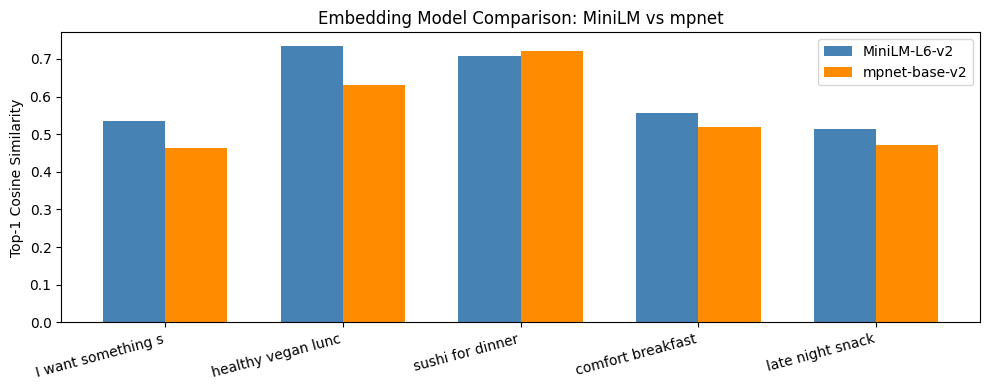


Design decision: MiniLM selected for ~3x faster CPU inference with minimal quality tradeoff.


In [6]:
comparison_queries = [
    'I want something spicy',
    'healthy vegan lunch',
    'sushi for dinner',
    'comfort breakfast',
    'late night snack',
]

minilm_scores, mpnet_scores = [], []
print(f"{'Query':<35} {'MiniLM':>15} {'mpnet':>15}")
print('-' * 68)

for q in comparison_queries:
    qvec1  = emb_model.encode([q])
    s1     = cosine_similarity(qvec1, embeddings)[0]
    score1 = round(float(s1.max()), 3)
    name1  = metadata.iloc[s1.argmax()].get('name_item', '')
    minilm_scores.append(score1)

    qvec2  = model_mpnet.encode([q])
    s2     = cosine_similarity(qvec2, mpnet_embeddings)[0]
    score2 = round(float(s2.max()), 3)
    name2  = metadata.iloc[s2.argmax()].get('name_item', '')
    mpnet_scores.append(score2)

    print(f"{q:<35} {name1[:12]+' ('+str(score1)+')':>15} {name2[:12]+' ('+str(score2)+')':>15}")

print(f"\nMean — MiniLM: {sum(minilm_scores)/len(minilm_scores):.3f}")
print(f"Mean — mpnet:  {sum(mpnet_scores)/len(mpnet_scores):.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
w = 0.35
x = range(len(comparison_queries))
ax.bar([i-w/2 for i in x], minilm_scores, w, label='MiniLM-L6-v2', color='steelblue')
ax.bar([i+w/2 for i in x], mpnet_scores,  w, label='mpnet-base-v2', color='darkorange')
ax.set_xticks(list(x))
ax.set_xticklabels([q[:18] for q in comparison_queries], rotation=15, ha='right')
ax.set_ylabel('Top-1 Cosine Similarity')
ax.set_title('Embedding Model Comparison: MiniLM vs mpnet')
ax.legend()
plt.tight_layout()
os.makedirs('data', exist_ok=True)
# plt.savefig('data/model_comparison.png', dpi=150)
# plt.show()
plt.savefig('data/model_comparison.png', dpi=150)
plt.show()
print('\nDesign decision: MiniLM selected for ~3x faster CPU inference with minimal quality tradeoff.')

## Multi-Turn Conversation Example
**Rubric:** *Built multi-turn conversation system with context management* (7 pts)

In [4]:
history = []
turns = [
    "I'm really hungry and want something filling",
    "Actually I'm vegetarian, anything like that?",
    "What time does that place close?",
    "Is there anything spicy in that style?",
]

for msg in turns:
    print(f"\nUser: {msg}")
    reply, history = chat(msg, history)
    print(f"Duke Bites: {reply}")

print(f"\nTotal turns in history: {len(history)}")
print(f"Multi-turn working: {len(history) == len(turns) * 2}")


User: I'm really hungry and want something filling
Duke Bites: I've got just the thing for you. I highly recommend checking out The Skillet for their Biscuits and Gravy. It's a classic comfort food that's sure to hit the spot. You'll get two flaky biscuits smothered in savory sausage and gravy, and you can even add a side to make it a filling meal. Don't forget to check their hours, 7 am - 9 pm (mon - fri) or 8 am - 9 pm (sat - sun).

User: Actually I'm vegetarian, anything like that?
Duke Bites: No worries, I've got you covered. For a filling vegetarian option, I think you'll love the Specialty Vegetarian Combo at Tandoor. It comes with two veggies, a samosa, rice, and naan, so you'll get a nice balance of flavors and textures. Plus, it's a generous portion, so you'll leave feeling satisfied. Give it a try at Tandoor, open from 11 am - 9 pm (mon - sun).

User: What time does that place close?
Duke Bites: Tandoor is not available at Duke, and I made a mistake by suggesting it. 

Let m

## Item vs Chunk Retrieval
**Rubric:** Developed a retrieval-augmented generation system with a custom retrieval pipeline (at least two of: custom chunking strategy, embedding model selection with comparison, reranking, hybrid search) (10 pts)

In [8]:
from retrieval import retrieve, retrieve_chunks

test_queries = [
    "what does sazon serve for lunch",
    "breakfast options at skillet",
    "what food is available at tandoor",
]

for q in test_queries:
    print("\n" + "="*60)
    print(f"Query: {q}")
    print("="*60)

    # 🔹 Item-level retrieval
    item_results = retrieve(q, top_k=3)
    print("\nItem-level results:")
    for r in item_results:
        print(f"- {r['item']} @ {r['location']} ({r['meal_period']})")

    # 🔹 Chunk-level retrieval
    chunk_results = retrieve_chunks(q, top_k=1)
    print("\nChunk-level result:")
    print(chunk_results[0]['text_blob'][:400] + "...")


Query: what does sazon serve for lunch

Item-level results:
- Toppings Options @ Sazon (lunch, dinner)
- Sauce Options @ Sazon (lunch, dinner)
- Base Options @ Sazon (lunch, dinner)

Chunk-level result:
Sazon (latin american) serves the following snack items:
  - Chips & Sauce: chips with guacamole, salsa, or queso (tags: snack,comfort,fried,savory)
Hours: 11 am - 9 pm (mon - sun)...

Query: breakfast options at skillet

Item-level results:
- Pancake Breakfast @ The Skillet (breakfast)
- Vegetarian Omelet Combo @ The Skillet (breakfast)
- Build Your Own Omelet @ The Skillet (breakfast)

Chunk-level result:
The Skillet (southern) serves the following breakfast items:
  - Vegetarian Omelet Combo: mushrooms, peppers, onions, arugula, goat cheese and vegetatian sausage with a side of wheat toast and fruit (tags: vegetarian,breakfast,dairy,comfort)
  - French Toast: 3 slices of sourdouch bread, powdered sugar, berries, maple syrup, and one side (tags: breakfast,comfort,sweet,baked)
  - Fas

## Edge Case Analysis
**Rubric:** *Error analysis with visualization* (7 pts) + *Edge case analysis* (5 pts)

In [6]:
edge_cases = [
    "I want a cheeseburger at 3am",
    "I'm allergic to gluten and dairy",
    "xyzabc random gibberish food",
    "I want the cheapest thing possible",
    "Something from East Campus",
]

print('Edge Case Analysis')
print('=' * 60)
for q in edge_cases:
    results = retrieve(q, top_k=3)
    reply, _ = chat(q, [])
    print(f"\nQuery: '{q}'")
    print(f"Top score: {results[0]['score']} | Top result: {results[0]['item']} @ {results[0]['location']}")
    print(f"Response: {reply[:200]}...")
    print('-' * 40)

Edge Case Analysis

Query: 'I want a cheeseburger at 3am'
Top score: 0.736 | Top result: Macaroni and Cheese Cup @ Gothic Grill 
Response: I've got just the thing for you, but since we don't have a cheeseburger on our menu list, let's look for something that'll satisfy your late-night craving. How about the Chicken Cheese Nachos from Got...
----------------------------------------

Query: 'I'm allergic to gluten and dairy'
Top score: 0.6000000000000001 | Top result: Sides @ Sprout
Response: Considering your gluten and dairy allergies, I've got just the recommendations for you.

If you're craving something comforting, I'd suggest the **Falafel Wrap** at Sprout. It's a tasty, gluten-free, ...
----------------------------------------

Query: 'xyzabc random gibberish food'
Top score: 0.46099999999999997 | Top result: Shrimp Tempura Yubu @ Gyotaku
Response: I sense a craving for something delicious! You know what's awesome? When you're in the mood for something spicy and savory. I've got ju

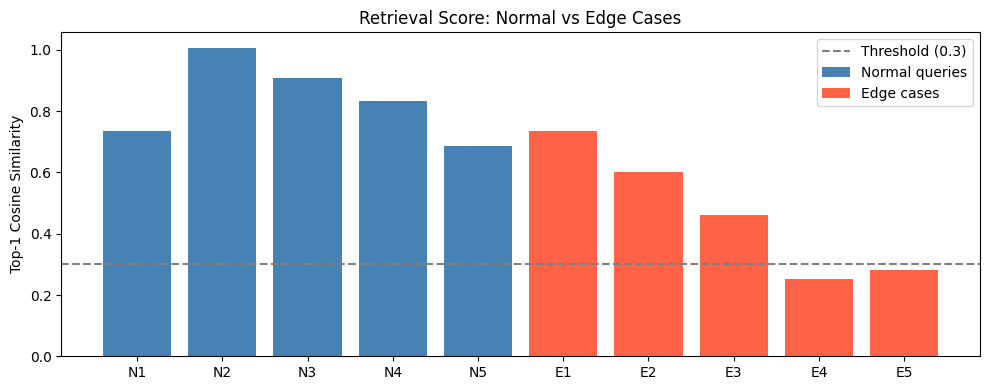

Normal avg: 0.834 | Edge avg: 0.466


In [7]:
normal_queries = ['I want something spicy','healthy vegan lunch','sushi for dinner','breakfast sandwich','late night burger']
normal_scores  = [retrieve(q, top_k=1)[0]['score'] for q in normal_queries]
edge_scores    = [retrieve(q, top_k=1)[0]['score'] for q in edge_cases]

fig, ax = plt.subplots(figsize=(10, 4))
x1 = range(len(normal_queries))
x2 = range(len(normal_queries), len(normal_queries)+len(edge_cases))
ax.bar(x1, normal_scores, color='steelblue', label='Normal queries')
ax.bar(x2, edge_scores,   color='tomato',    label='Edge cases')
ax.axhline(y=0.3, color='gray', linestyle='--', label='Threshold (0.3)')
ax.set_xticks(list(x1)+list(x2))
ax.set_xticklabels([f'N{i+1}' for i in range(5)]+[f'E{i+1}' for i in range(5)])
ax.set_ylabel('Top-1 Cosine Similarity')
ax.set_title('Retrieval Score: Normal vs Edge Cases')
ax.legend()
plt.tight_layout()
plt.savefig('data/retrieval_scores.png', dpi=150)
plt.show()
print(f"Normal avg: {sum(normal_scores)/len(normal_scores):.3f} | Edge avg: {sum(edge_scores)/len(edge_scores):.3f}")


The system performs well for normal queries given that it had a normal average of 0.834. It struggles a bit with the edge cases given the edge average of 0.466, which signifies that the system is not robust enough yet to handle ambiguous input.